# 01 — Coleta e Pré-processamento dos Dados

**Seção 1**:
- Download PETR4.SA, Brent (BZ=F), USD/BRL (USDBRL=X), Ibovespa (^BVSP)
- Limpeza, ajuste de splits, alinhamento temporal
- Detecção de outliers (sinalizar, não remover)
- Construção do target binário

In [1]:
import sys
import os
import logging

# Adicionar raiz do projeto ao path
sys.path.insert(0, os.path.abspath('..'))

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

## 1.1 Coleta de Dados

In [2]:
from src.data.collector import download_all_assets, save_raw_data, ASSETS_CONFIG

print("Ativos configurados:")
for name, config in ASSETS_CONFIG.items():
    print(f"  {name}: {config['symbol']} — {config['description']}")

Ativos configurados:
  petr4: PETR4.SA — Petrobras PN - Ativo principal
  brent: BZ=F — Petróleo Brent - Feature exógena (principal driver)
  usdbrl: USDBRL=X — Dólar/Real - Feature exógena (exposição cambial)
  ibov: ^BVSP — Ibovespa - Feature exógena (contexto de mercado)


In [3]:
# Download de todos os ativos (period='max', interval='1d')
data_raw = download_all_assets(period='max', interval='1d')

for name, df in data_raw.items():
    print(f"\n{name}: {df.shape}")
    print(f"  Período: {df.index.min().date()} a {df.index.max().date()}")
    print(f"  Colunas: {df.columns.tolist()}")
    display(df.head(3))

2026-04-20 13:58:30,883 - src.data.collector - INFO - Baixando dados de PETR4.SA (period=max, interval=1d)
2026-04-20 13:58:34,091 - src.data.collector - INFO -   -> PETR4.SA: 6601 registros, de 2000-01-03 a 2026-04-20
2026-04-20 13:58:34,092 - src.data.collector - INFO -   ✓ Petrobras PN - Ativo principal
2026-04-20 13:58:34,092 - src.data.collector - INFO - Baixando dados de BZ=F (period=max, interval=1d)
2026-04-20 13:58:34,091 - src.data.collector - INFO -   -> PETR4.SA: 6601 registros, de 2000-01-03 a 2026-04-20
2026-04-20 13:58:34,092 - src.data.collector - INFO -   ✓ Petrobras PN - Ativo principal
2026-04-20 13:58:34,092 - src.data.collector - INFO - Baixando dados de BZ=F (period=max, interval=1d)
2026-04-20 13:58:34,809 - src.data.collector - INFO -   -> BZ=F: 4659 registros, de 2007-07-30 a 2026-04-20
2026-04-20 13:58:34,810 - src.data.collector - INFO -   ✓ Petróleo Brent - Feature exógena (principal driver)
2026-04-20 13:58:34,810 - src.data.collector - INFO - Baixando dado


petr4: (6601, 5)
  Período: 2000-01-03 a 2026-04-20
  Colunas: ['Close', 'High', 'Low', 'Open', 'Volume']


Price,Close,High,Low,Open,Volume
Date,,,,,
2000-01-03,1.120992,1.120992,1.120992,1.120992,35389440000
2000-01-04,1.058978,1.058978,1.058978,1.058978,28861440000
2000-01-05,1.048293,1.048293,1.048293,1.048293,43033600000



brent: (4659, 5)
  Período: 2007-07-30 a 2026-04-20
  Colunas: ['Close', 'High', 'Low', 'Open', 'Volume']


Price,Close,High,Low,Open,Volume
Date,,,,,
2007-07-30,75.739998,76.529999,75.440002,75.849998,2575
2007-07-31,77.050003,77.169998,75.669998,75.699997,3513
2007-08-01,75.349998,77.059998,74.860001,77.000000,3930



usdbrl: (5389, 5)
  Período: 2003-12-01 a 2026-04-20
  Colunas: ['Close', 'High', 'Low', 'Open', 'Volume']


Price,Close,High,Low,Open,Volume
Date,,,,,
2003-12-01,2.923,2.946,2.923,2.946,0
2003-12-02,2.931,2.931,2.923,2.923,0
2003-12-03,2.931,2.936,2.926,2.931,0



ibov: (8168, 5)
  Período: 1993-04-27 a 2026-04-20
  Colunas: ['Close', 'High', 'Low', 'Open', 'Volume']


Price,Close,High,Low,Open,Volume
Date,,,,,
1993-04-27,24.500000,25.400000,24.500000,24.799999,0
1993-04-28,24.299999,24.600000,23.700001,24.500000,0
1993-04-29,23.700001,24.799999,23.700001,24.299999,0


In [4]:
# Salvar dados brutos
save_raw_data(data_raw, output_dir='../data/raw')
print("Dados brutos salvos em data/raw/")

2026-04-20 14:00:11,739 - src.data.collector - INFO - Salvo: ..\data\raw\petr4_raw.csv (6601 registros)
2026-04-20 14:00:11,758 - src.data.collector - INFO - Salvo: ..\data\raw\brent_raw.csv (4659 registros)
2026-04-20 14:00:11,758 - src.data.collector - INFO - Salvo: ..\data\raw\brent_raw.csv (4659 registros)
2026-04-20 14:00:11,788 - src.data.collector - INFO - Salvo: ..\data\raw\usdbrl_raw.csv (5389 registros)
2026-04-20 14:00:11,788 - src.data.collector - INFO - Salvo: ..\data\raw\usdbrl_raw.csv (5389 registros)
2026-04-20 14:00:11,828 - src.data.collector - INFO - Salvo: ..\data\raw\ibov_raw.csv (8168 registros)
2026-04-20 14:00:11,828 - src.data.collector - INFO - Salvo: ..\data\raw\ibov_raw.csv (8168 registros)


Dados brutos salvos em data/raw/


## 1.2 Pré-processamento

In [5]:
from src.data.preprocessor import preprocess_all

data_clean, target, outlier_flags = preprocess_all(data_raw)

2026-04-20 14:00:34,848 - src.data.preprocessor - INFO - ============================================================
2026-04-20 14:00:34,849 - src.data.preprocessor - INFO - INÍCIO DO PRÉ-PROCESSAMENTO
2026-04-20 14:00:34,849 - src.data.preprocessor - INFO - ============================================================
2026-04-20 14:00:34,850 - src.data.preprocessor - INFO - 
1. Ajustando OHLC por splits/proventos...
2026-04-20 14:00:34,851 - src.data.preprocessor - INFO - 
2. Limpeza individual dos ativos...
2026-04-20 14:00:34,852 - src.data.preprocessor - INFO -   petr4: removendo 146 dias com volume zero
2026-04-20 14:00:34,853 - src.data.preprocessor - INFO -   petr4: 146 registros removidos na limpeza
2026-04-20 14:00:34,854 - src.data.preprocessor - INFO -   brent: removendo 13 dias com volume zero
2026-04-20 14:00:34,855 - src.data.preprocessor - INFO -   brent: 13 registros removidos na limpeza
2026-04-20 14:00:34,857 - src.data.preprocessor - INFO -   ibov: removendo 3368 dia

In [6]:
# Verificar resultado
print(f"\nAtivo principal (PETR4):")
print(f"  Shape: {data_clean['petr4'].shape}")
print(f"  Período: {data_clean['petr4'].index.min().date()} a {data_clean['petr4'].index.max().date()}")
print(f"\nTarget:")
print(f"  Positivos (1): {target.sum():.0f} ({target.mean()*100:.1f}%)")
print(f"  Negativos (0): {(1-target).sum():.0f}")
print(f"  NaN: {target.isna().sum()}")
print(f"\nOutliers detectados: {outlier_flags.any(axis=1).sum()} datas")


Ativo principal (PETR4):
  Shape: (4332, 5)
  Período: 2007-07-30 a 2026-04-17

Target:
  Positivos (1): 2273 (52.5%)
  Negativos (0): 2058
  NaN: 1

Outliers detectados: 658 datas


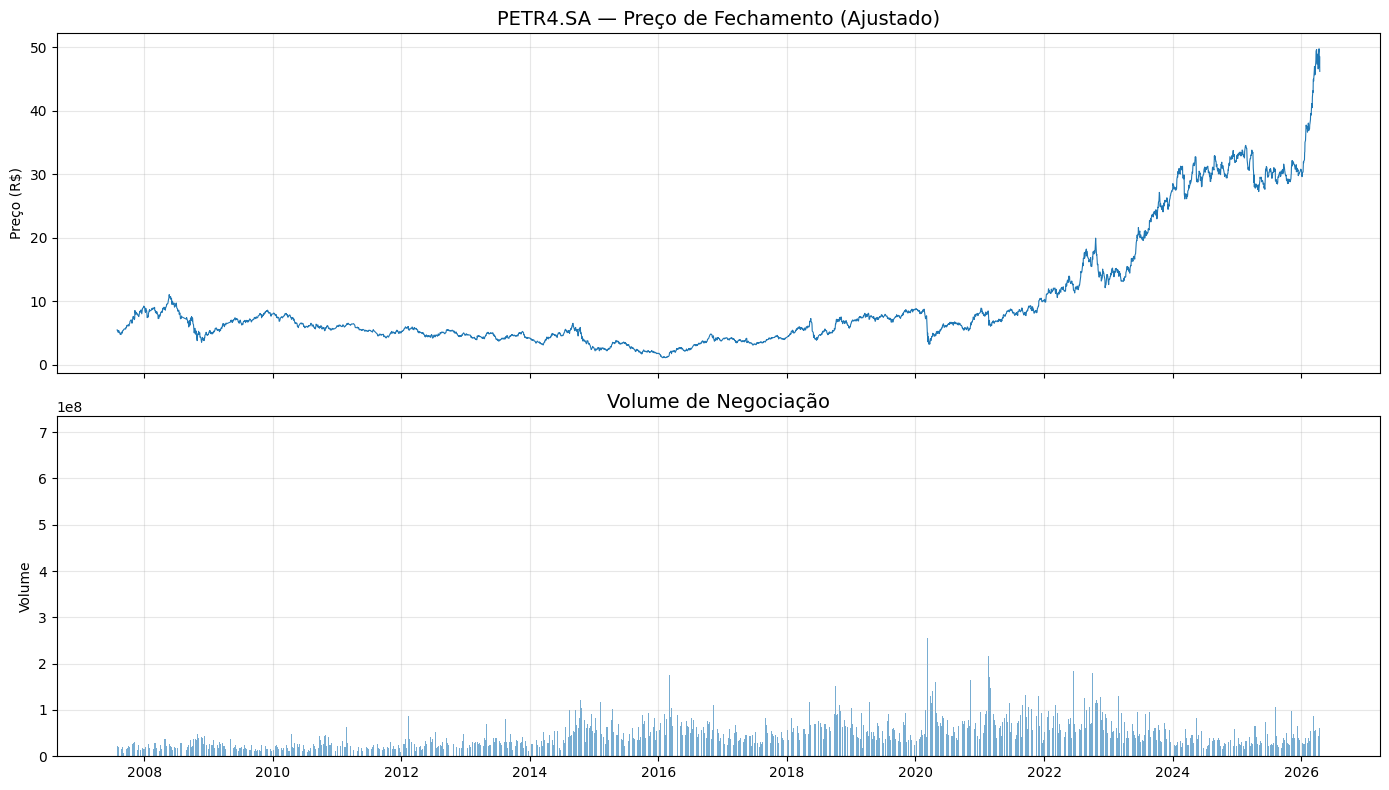

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Preço de fechamento
axes[0].plot(data_clean['petr4'].index, data_clean['petr4']['Close'], linewidth=0.8)
axes[0].set_title('PETR4.SA — Preço de Fechamento (Ajustado)', fontsize=14)
axes[0].set_ylabel('Preço (R$)')
axes[0].grid(True, alpha=0.3)

# Volume
axes[1].bar(data_clean['petr4'].index, data_clean['petr4']['Volume'], width=1, alpha=0.6)
axes[1].set_title('Volume de Negociação', fontsize=14)
axes[1].set_ylabel('Volume')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Salvar dados processados
import pandas as pd

for name, df in data_clean.items():
    df.to_csv(f'../data/processed/{name}_clean.csv')
    print(f"Salvo: data/processed/{name}_clean.csv")

target.to_csv('../data/processed/target.csv', header=True)
print("Salvo: data/processed/target.csv")

print("\n✅ Etapa 1 concluída — dados prontos para Feature Engineering.")

Salvo: data/processed/petr4_clean.csv
Salvo: data/processed/brent_clean.csv
Salvo: data/processed/usdbrl_clean.csv
Salvo: data/processed/ibov_clean.csv
Salvo: data/processed/target.csv

✅ Etapa 1 concluída — dados prontos para Feature Engineering.
